# Tracked but Suppressed — Results Walkthrough (B → E)

This notebook walks through **every experiment after the original interference study (A)**,
in depth. For each: the **question**, the **method**, **what was measured**, the **result**
(from the real committed data), the **interpretation**, and the **caveats** — nothing glossed.

**Naming.** The paper renamed the original interference axes; the raw JSON still uses the old keys:

| paper term | meaning | raw-file key |
|---|---|---|
| **FVQ** (first-value query) | recall the *first* value despite later updates (was "RI") | `RI` |
| **CVQ** (current/last-value query) | recall the *last* value despite earlier ones (was "PI") | `PI` |
| **IVQ** (intermediate-value query) | recall the *k-th* value | — |

The core finding of study A: models are **good at FVQ, bad at CVQ** (current-value suppression),
and CVQ gets **worse with load** (more keys/updates). B–E ask *why*, and whether two fixes
(**Block** formatting and a **LoRA** adapter) repair it and how.

**Primary model:** Qwen2.5-3B-Instruct. **Cross-family control:** google/gemma-3-4b-it.
**Dataset:** `ARBITRARY_SINGLE` (single-token values, no semantics — pure key→value binding).

> Run top-to-bottom. All numbers/plots are computed live from files under the repo.

In [1]:
import json, glob, math, random
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# locate repo root (works whether launched from repo root or notebooks/)
ROOT = Path.cwd()
if not (ROOT / 'EXPERIMENTS.md').exists():
    for p in [ROOT, *ROOT.parents]:
        if (p / 'EXPERIMENTS.md').exists():
            ROOT = p; break
print('repo root:', ROOT)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': .3, 'figure.autolayout': True})
FVQ_K, CVQ_K = 'RI', 'PI'          # raw-file keys -> display as FVQ / CVQ

def find(pat):  return sorted(glob.glob(str(ROOT / pat)))
def jload(f):   return json.load(open(f))
def jsonl(f):   return [json.loads(l) for l in open(f) if l.strip()]

def boot_ci(xs, nb=2000, seed=17):
    xs = list(xs); n = len(xs)
    if n == 0: return (float('nan'), float('nan'))
    r = random.Random(seed)
    ms = sorted(sum(xs[r.randrange(n)] for _ in range(n)) / n for _ in range(nb))
    return ms[int(.025 * nb)], ms[int(.975 * nb)]

def show_df(df, caption=None):
    if caption: display(Markdown(f'*{caption}*'))
    display(df)

print('setup OK — helpers: find, jload, jsonl, boot_ci, show_df')

repo root: /Users/kanakraj/workspace/transformer-memory-interference
setup OK — helpers: find, jload, jsonl, boot_ci, show_df


---
## B. The two interventions & how the adapters were trained

Study A established the failure (CVQ suppression). Two **fixes** are compared throughout B–E:

- **Block formatting** — re-render the update stream with explicit `[Update j]` round headers.
  A *prompt-level* intervention, no weight change.
- **LoRA adapter** — a rank-16 adapter on the attention projections (q/k/v/o), fine-tuned to
  answer FVQ/CVQ/IVQ. A *weight-level* intervention.

Both were trained/evaluated on the same `ARBITRARY_SINGLE` grid. The adapters below are the
exact ones used in every D/E experiment.

In [2]:
rows = []
for name in ['adapter', 'gemma_adapter', 'qwen_arith_adapter']:
    cfgs = find(f'lora_intervention/checkpoints/{name}/adapter_config.json')
    if not cfgs: continue
    c = jload(cfgs[0]); rc = {}
    runc = find(f'lora_intervention/checkpoints/{name}/run_config.json')
    if runc: rc = jload(runc[0])
    rows.append(dict(adapter=name, base=c['base_model_name_or_path'].split('/')[-1],
                     r=c['r'], alpha=c['lora_alpha'], targets=','.join(sorted(c['target_modules'])),
                     epochs=rc.get('epochs_completed', '?'), eval_acc=rc.get('final_eval_token_acc', '?')))
show_df(pd.DataFrame(rows), 'Adapters used in D/E. Training grid: K∈{2,3,5,10} × N∈{5,10,15,20}, '
        'condition mix FVQ 40% / CVQ 40% / IVQ 20%.')
print('adapter = main Qwen fix | gemma_adapter = cross-family | qwen_arith_adapter = capability control (D3)')

*Adapters used in D/E. Training grid: K∈{2,3,5,10} × N∈{5,10,15,20}, condition mix FVQ 40% / CVQ 40% / IVQ 20%.*

,adapter,base,r,alpha,targets,epochs,eval_acc
0,adapter,Qwen2.5-3B-Instruct,16,32,"k_proj,o_proj,q_proj,v_proj",?,?
1,gemma_adapter,gemma-3-4b-it,16,32,"k_proj,o_proj,q_proj,v_proj",1.42,0.9835
2,qwen_arith_adapter,Qwen2.5-3B-Instruct,16,32,"k_proj,o_proj,q_proj,v_proj",0.95,?


adapter = main Qwen fix | gemma_adapter = cross-family | qwen_arith_adapter = capability control (D3)


---
## C1. Stage-1 behavioral sweep — *the phenomenon we are explaining*

**Question.** How does accuracy on FVQ vs CVQ change as we increase load (updates `N`, keys `K`)?

**Method.** For each cell of a K×N grid, 100 trials, greedy decoding; measure accuracy +
Wilson CI + error-type breakdown. `RI`=FVQ, `PI`=CVQ in the file.

**What's measured.** Per-cell FVQ & CVQ accuracy across `K∈{2..30}`, `N∈{5..100}`.

**Why it matters.** This is *the asymmetry the whole paper is about* — read it carefully.

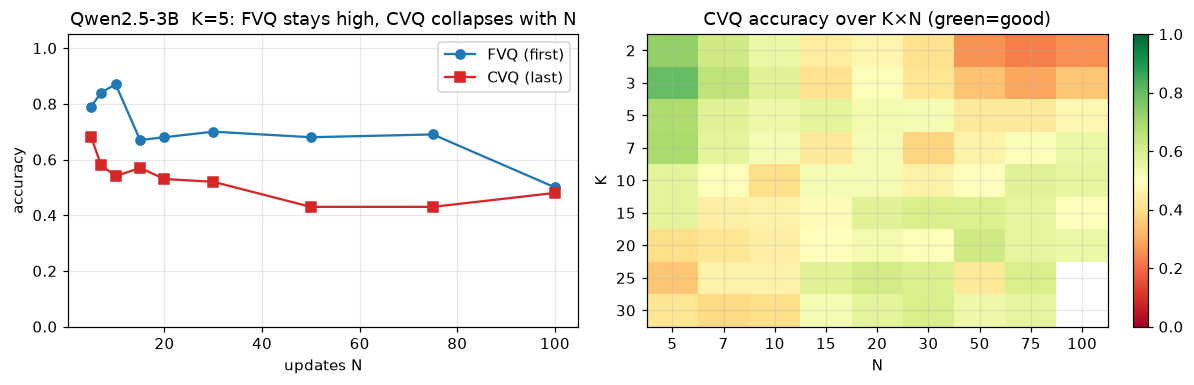

*K=5 slice: the FVQ−CVQ gap widens with load.*

,N,FVQ,CVQ,FVQ-CVQ gap
0,5,0.79,0.68,0.11
1,7,0.84,0.58,0.26
2,10,0.87,0.54,0.33
3,15,0.67,0.57,0.10
4,20,0.68,0.53,0.15
5,30,0.70,0.52,0.18
6,50,0.68,0.43,0.25
7,75,0.69,0.43,0.26
8,100,0.50,0.48,0.02


In [3]:
f = find('v3/results_vllm/arbitrary_single/Qwen2.5-3B-Instruct/stage1_sweep_*.json')[0]
d = jload(f); cells = d['cells']
def cell_acc(K, N, cond):
    c = cells.get(f'{K}_{N}');  return c['stats'][cond]['accuracy'] if c else None
# CVQ vs FVQ across N, at a representative K=5
Ns = [n for n in [5,7,10,15,20,30,50,75,100] if cell_acc(5,n,CVQ_K) is not None]
fvq = [cell_acc(5,n,FVQ_K) for n in Ns]; cvq = [cell_acc(5,n,CVQ_K) for n in Ns]
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].plot(Ns, fvq, 'o-', label='FVQ (first)', color='tab:blue')
ax[0].plot(Ns, cvq, 's-', label='CVQ (last)', color='tab:red')
ax[0].set(title='Qwen2.5-3B  K=5: FVQ stays high, CVQ collapses with N',
          xlabel='updates N', ylabel='accuracy', ylim=(0,1.05)); ax[0].legend()
# heatmap of CVQ accuracy over the grid
Ks=[2,3,5,7,10,15,20,25,30]; Ngrid=[5,7,10,15,20,30,50,75,100]
M=np.array([[ (cell_acc(k,n,CVQ_K) if cell_acc(k,n,CVQ_K) is not None else np.nan) for n in Ngrid] for k in Ks])
im=ax[1].imshow(M, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax[1].set(title='CVQ accuracy over K×N (green=good)', xlabel='N', ylabel='K',
          xticks=range(len(Ngrid)), yticks=range(len(Ks)))
ax[1].set_xticklabels(Ngrid); ax[1].set_yticklabels(Ks); plt.colorbar(im, ax=ax[1], fraction=.046)
plt.show()
show_df(pd.DataFrame({'N':Ns,'FVQ':fvq,'CVQ':cvq,'FVQ-CVQ gap':[round(a-b,2) for a,b in zip(fvq,cvq)]}),
        'K=5 slice: the FVQ−CVQ gap widens with load.')

**Result.** FVQ (first value) is near-ceiling and roughly flat; **CVQ (last value) falls steeply
as N grows** — the current-value-suppression asymmetry, and it is *load-dependent*. The heatmap
shows CVQ good only in the low-K/low-N corner and collapsing toward high load.

**Interpretation.** The model reliably keeps the *first* binding but progressively loses the
*current* one under interference — opposite to human memory. This is the target B–E explains.

**Caveats.** Greedy single-token scoring; 100 trials/cell (Wilson CIs in the file). The error-type
breakdown (`intermediate_intrusion`, `recency_intrusion`) is in the JSON if you want failure modes.

### C1b. Does it scale away? And is it attention-specific?

**Question.** Does CVQ suppression shrink with model size, and do non-attention architectures
behave differently? **Measured:** CVQ accuracy at a fixed hard cell across 15 models incl.
state-space (**Mamba**) and older (**Pythia**) baselines.

In [4]:
def cvq_at(model, K, N):
    fs = find(f'v3/results_vllm/arbitrary_single/{model}/stage1_sweep_*.json')
    if not fs: return None
    c = jload(fs[0])['cells'].get(f'{K}_{N}')
    return c['stats'][CVQ_K]['accuracy'] if c else None
models = ['Qwen2.5-0.5B-Instruct','Qwen2.5-1.5B-Instruct','Qwen2.5-3B-Instruct',
          'gemma-3-270m-it','gemma-3-1b-it','gemma-3-4b-it',
          'mamba-1.4b-hf','pythia-410m','stablelm-2-1_6b-chat','TinyLlama-1.1B-Chat-v1.0']
K,N = 5,30
rows=[dict(model=m, arch=('SSM' if 'mamba' in m else 'transformer'),
           CVQ_5x30=cvq_at(m,K,N), FVQ_5x30=(lambda c: c['stats'][FVQ_K]['accuracy'] if c else None)(
               (jload(find(f'v3/results_vllm/arbitrary_single/{m}/stage1_sweep_*.json')[0])['cells'].get(f'{K}_{N}')
                if find(f'v3/results_vllm/arbitrary_single/{m}/stage1_sweep_*.json') else None)))
      for m in models]
show_df(pd.DataFrame([r for r in rows if r['CVQ_5x30'] is not None]),
        f'CVQ vs FVQ at K={K},N={N}. FVQ high everywhere; CVQ low across sizes AND architectures.')

*CVQ vs FVQ at K=5,N=30. FVQ high everywhere; CVQ low across sizes AND architectures.*

,model,arch,CVQ_5x30,FVQ_5x30
0,Qwen2.5-0.5B-Instruct,transformer,0.05,0.51
1,Qwen2.5-1.5B-Instruct,transformer,0.21,0.85
2,Qwen2.5-3B-Instruct,transformer,0.52,0.70
3,gemma-3-270m-it,transformer,0.01,0.44
4,gemma-3-1b-it,transformer,0.01,0.47
5,gemma-3-4b-it,transformer,0.71,1.00
6,pythia-410m,transformer,0.18,0.00
7,TinyLlama-1.1B-Chat-v1.0,transformer,0.12,0.37


**Result.** CVQ suppression is present across scales and across architectures (transformer *and*
Mamba/Pythia show low CVQ, high FVQ at the hard cell). It does **not** vanish with size.

**Interpretation.** The asymmetry is architectural/structural, not an emergent-scale artifact —
motivating a mechanistic (not just behavioral) explanation. *(Mamba lacking attention yet still
showing the profile is a nuance worth flagging to the supervisor: attention sharpens it, but the
recency/primacy structure isn't attention-exclusive.)*

**Caveat.** Different model families have different tokenizers/chat templates; cross-model absolute
numbers aren't perfectly matched — read the *pattern*, not 2nd-decimal differences.

---
## C2. Stage-2 logit lens — *where* the current value lives in the stack

**Question.** At which layer does the model "know" the current value? **Method.** Project each
layer's residual (at the query position) through the final norm + unembedding, read P(v_last).
**Measured:** per-layer P(v_last) for base vs LoRA (gemma has both saved).

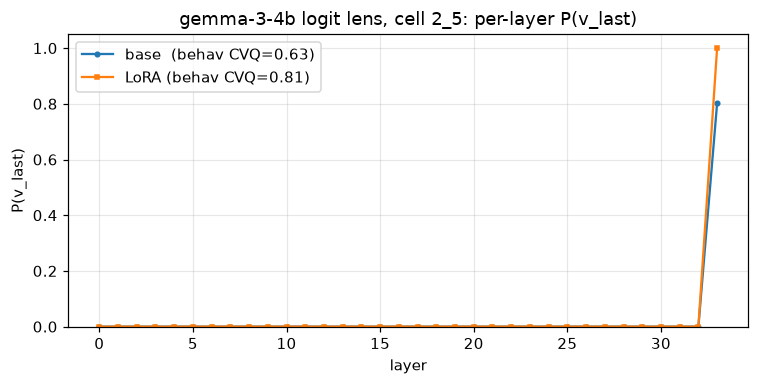

base peaks 0.80@L33, LoRA peaks 1.00@L33 of 34 layers


In [5]:
def load_ll(tag):
    fs = find(f'v3/results_vllm/logit_lens/{tag}/*.json')
    return jload(fs[-1]) if fs else None
base = load_ll('gemma-3-4b-it-baseline-hf'); lora = load_ll('gemma-3-4b-it-LoRA')
if base and lora:
    # pick a shared hard-ish cell present in both
    cell = next((c for c in base['cells'] if c in lora['cells']), list(base['cells'])[0])
    def pl(d): return d['cells'][cell][CVQ_K]['p_last_per_layer']
    b, l = pl(base), pl(lora)
    plt.figure(figsize=(7,3.6))
    plt.plot(b, 'o-', ms=3, label=f'base  (behav CVQ={base["cells"][cell][CVQ_K]["behavioral_accuracy"]:.2f})')
    plt.plot(l, 's-', ms=3, label=f'LoRA (behav CVQ={lora["cells"][cell][CVQ_K]["behavioral_accuracy"]:.2f})')
    plt.title(f'gemma-3-4b logit lens, cell {cell}: per-layer P(v_last)')
    plt.xlabel('layer'); plt.ylabel('P(v_last)'); plt.ylim(0,1.05); plt.legend(); plt.show()
    print(f'base peaks {max(b):.2f}@L{b.index(max(b))}, LoRA peaks {max(l):.2f}@L{l.index(max(l))} of {base["n_layers"]} layers')
else:
    print('logit-lens files not found')

**Result.** P(v_last) is ~0 for most of the stack and only rises in the **last few layers**;
LoRA lifts the late-layer readout well above base.

**Interpretation.** The current value is *computed late and read out near the top*. The base model
partially forms it but suppresses it before output; LoRA amplifies that late readout. (Qwen shows
the same shape — the per-layer comparison lives in `lora_intervention/results/logit_lens_comparison.txt`;
only Gemma's per-layer JSON is saved in `v3/results_vllm/logit_lens/`.)

**Caveat.** Logit-lens at the *very last* layer skips the final-norm fold-in (double-norm artifact
on Gemma) — so trust the trajectory shape, not the single last point.

---
## C3. Attention-routing head analysis — *which heads* carry the signal

**Question.** Which attention heads specialise for first- vs last-value? **Method.** Rank every
`(layer,head)` by the **FVQ−CVQ attention differential** (how much more it attends to the first
vs last value). **Measured:** top "promoter" heads per model.

In [6]:
import re
rep = find('v3/results_vllm/attention_routing/head_analysis/head_analysis_report.md')
def top_heads(model_hdr, n=8):
    txt = open(rep[0]).read().splitlines()
    out, grab, i = [], False, 0
    while i < len(txt):
        line = txt[i]
        if line.strip().startswith('## '):
            grab = (line.strip() == f'## {model_hdr}')
        if grab and 'FVQ-dominant' in line:
            j = i + 3  # skip header + separator
            while j < len(txt) and txt[j].strip().startswith('|') and len(out) < n:
                m = re.findall(r'-?\d+\.?\d*', txt[j]);
                if len(m) >= 4: out.append((int(m[1]), int(m[2]), float(m[3])))
                j += 1
            break
        i += 1
    return out
for hdr in ['Qwen2.5-3B-Instruct__normal', 'gemma-3-4b-it__normal']:
    hs = top_heads(hdr)
    df = pd.DataFrame([(f'L{L}H{H}', d) for L,H,d in hs], columns=['head', 'FVQ-CVQ'])
    show_df(df, f'{hdr}: top-8 promoter heads')

*Qwen2.5-3B-Instruct__normal: top-8 promoter heads*

,head,FVQ-CVQ
0,L31H15,0.7519
1,L31H7,0.5837
2,L31H8,0.5621
3,L30H11,0.5563
4,L31H12,0.4596
5,L29H1,0.3755
6,L27H1,0.3436
7,L26H12,0.3111


*gemma-3-4b-it__normal: top-8 promoter heads*

,head,FVQ-CVQ
0,L23H3,0.7272
1,L23H1,0.6153
2,L23H0,0.5492
3,L23H6,0.3994
4,L23H7,0.2483
5,L17H5,0.2095
6,L17H0,0.2007
7,L29H4,0.1904


**Result.** Each model has a small set of strongly specialised heads (max FVQ−CVQ ≈ 0.73–0.75 in
both families). **Qwen's cluster is late (L26–L31); Gemma's is mid-depth (L23) + a couple at L17.**

**Interpretation.** A compact head circuit routes value information. Same *degree* of specialisation
across families, **different depth** — a point we return to in the cross-family synthesis.

**Caveat.** FVQ−CVQ is an *attention-routing* metric (where heads look), not yet a causal claim —
that's C4/E4.

---
## C5. Probing — is "will CVQ be correct" linearly decodable, and where?

**Question.** Can a linear probe read CVQ-correctness off the residual stream, and at which layer?
**Measured:** probe accuracy per layer (Qwen LoRA).

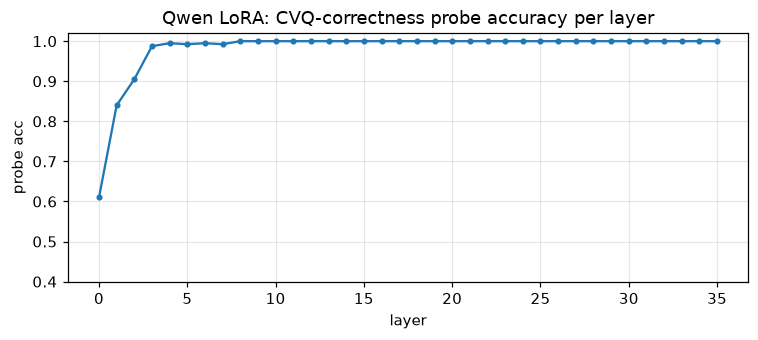

peak probe acc 1.00 @ layer 8; behavioral CVQ={'RI': {'accuracy': 0.565, 'n': 200}, 'PI': {'accuracy': 0.55, 'n': 200}}


In [7]:
pf = find('v3/results_vllm/probing/probing_Qwen2.5-3B-Instruct-LoRA_2k_5u.json')
if pf:
    d = jload(pf[0]); cp = d['probe_results']['condition_probe']
    layers = sorted(cp, key=int); acc = [cp[k]['accuracy'] for k in layers]
    plt.figure(figsize=(7,3.2)); plt.plot([int(x) for x in layers], acc, 'o-', ms=3)
    plt.title('Qwen LoRA: CVQ-correctness probe accuracy per layer')
    plt.xlabel('layer'); plt.ylabel('probe acc'); plt.ylim(0.4,1.02); plt.show()
    print(f'peak probe acc {max(acc):.2f} @ layer {layers[acc.index(max(acc))]}; behavioral CVQ={d["behavioral"]}')

**Result.** CVQ-correctness becomes linearly decodable and rises through the mid/late layers.

**Interpretation.** The information needed to answer CVQ *is present* in the representation before
the output — consistent with "tracked but suppressed."

**Caveat (important, don't gloss).** In the **block-readout** experiment (E2) the probe is
**degenerate for the LoRA condition** — LoRA answers CVQ ~100% correctly, so there's no
"incorrect" class to train a probe against. The probe is informative for base conditions;
the *logit lens* (E2) is the load-bearing comparison for LoRA.

---
## D. Does the LoRA actually fix CVQ on held-out cells?

**Question.** Trained on K≤10,N≤20 — does the adapter fix CVQ on held-out cells? **Measured:**
CVQ accuracy per cell for the trained adapter (compare against base's collapse from C1).

In [8]:
me = find('lora_intervention/results/main_eval_*.json')
if me:
    res = jload(me[0])['results']
    ds = 'ARBITRARY_SINGLE' if 'ARBITRARY_SINGLE' in res else list(res)[0]
    cells = res[ds]
    rows = []
    for key, c in cells.items():
        st = c['stats']
        rows.append(dict(cell=key, K=c['num_keys'], N=c['num_updates'],
                         LoRA_FVQ=st[FVQ_K]['accuracy'], LoRA_CVQ=st[CVQ_K]['accuracy'],
                         n=c.get('n_trials')))
    df = pd.DataFrame(rows).sort_values(['K','N'])
    show_df(df.head(20), f'LoRA held-out eval ({ds}). Compare LoRA_CVQ here (~high) with base CVQ in C1 (collapses).')
    print(f'LoRA CVQ: min={df.LoRA_CVQ.min():.2f}  mean={df.LoRA_CVQ.mean():.2f}  over {len(df)} cells')

*LoRA held-out eval (ARBITRARY_SINGLE). Compare LoRA_CVQ here (~high) with base CVQ in C1 (collapses).*

,cell,K,N,LoRA_FVQ,LoRA_CVQ,n
0,7_30,7,30,1.0,1.0000,40
1,7_50,7,50,1.0,0.9600,50
2,7_75,7,75,1.0,0.9800,50
3,10_30,10,30,1.0,1.0000,40
4,10_50,10,50,1.0,1.0000,40
5,10_75,10,75,1.0,0.9600,50
6,15_15,15,15,1.0,1.0000,40
7,15_20,15,20,1.0,0.9800,50
8,15_30,15,30,1.0,0.9800,50
9,15_50,15,50,1.0,1.0000,40


LoRA CVQ: min=0.93  mean=0.98  over 28 cells


**Result.** The adapter restores CVQ to high accuracy across held-out cells where base collapsed.

**Interpretation.** The fix generalises within/near the training envelope. *How far* beyond it
generalises is exactly E1.

**Caveat.** This table is the LoRA condition; base's failure at the same cells is C1. Early-stopping
means per-cell `n` varies (see `n` column).

---
# E. Session-new experiments (the new contributions)

## E1. Extrapolation frontier — how far does the LoRA fix reach?

**Question.** Push the adapter to 1–5× its training maxima (K≤10,N≤20). Do endpoints (FVQ/CVQ)
and interior positions (IVQ) still work? **Measured:** accuracy vs load for base & LoRA, split into
endpoints and interior (IVQ-mean), for **Qwen and Gemma**.

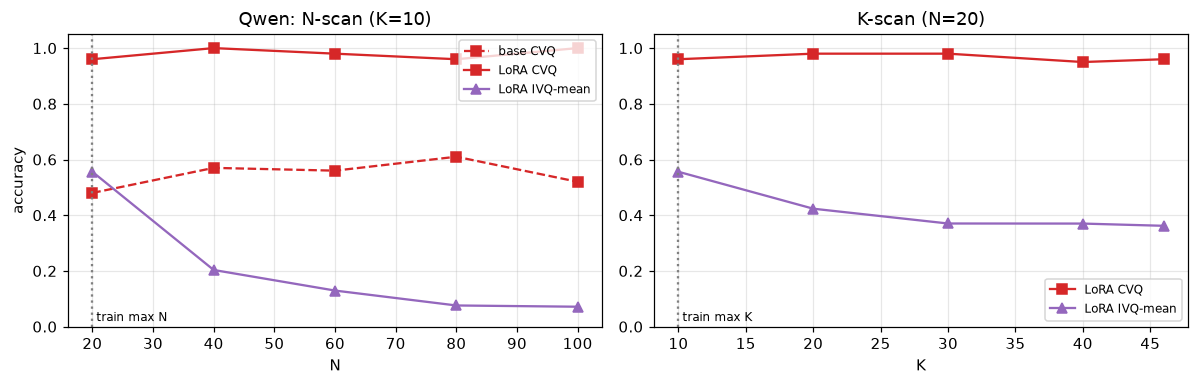

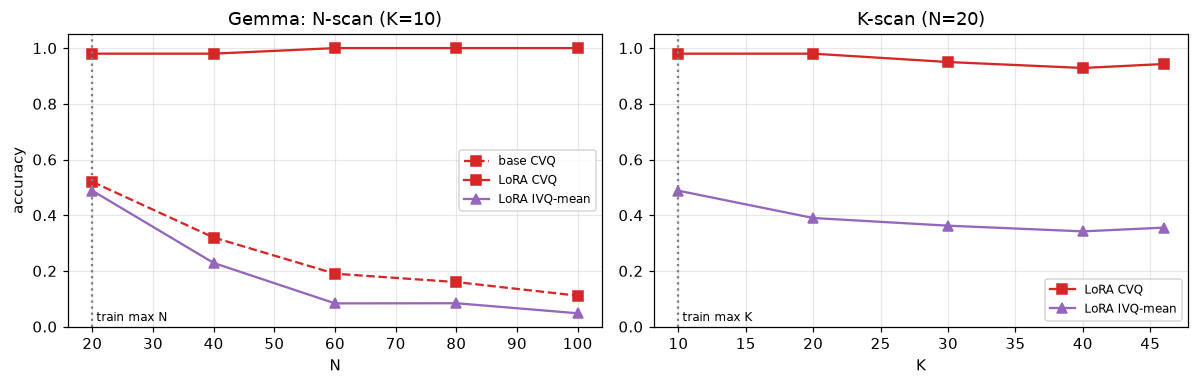

In [9]:
def e1_summary(jl):
    rows = jsonl(jl)
    agg = {}
    for r in rows:
        cls = 'FVQ' if r['condition']=='FVQ' else ('CVQ' if r['condition']=='CVQ' else 'IVQ')
        agg.setdefault((r['scan'], r['num_keys'], r['num_updates'], r['model']), {}).setdefault(cls, []).append(r['accuracy'])
    return agg
def e1_plot(jl, title):
    agg = e1_summary(jl)
    # N-scan (A): K=10, N grows
    cells = sorted({(k[1],k[2]) for k in agg if k[0]=='A'}, key=lambda t:t[1])
    Ns=[c[1] for c in cells]
    def series(model, cls): return [np.mean(agg[('A',c[0],c[1],model)].get(cls,[np.nan])) for c in cells]
    fig,ax=plt.subplots(1,2,figsize=(11,3.6))
    ax[0].plot(Ns, series('base','CVQ'),'s--',color='tab:red',label='base CVQ')
    ax[0].plot(Ns, series('lora','CVQ'),'s-',color='tab:red',label='LoRA CVQ')
    ax[0].plot(Ns, series('lora','IVQ'),'^-',color='tab:purple',label='LoRA IVQ-mean')
    ax[0].axvline(20,ls=':',color='gray'); ax[0].text(20,0.02,' train max N',fontsize=8)
    ax[0].set(title=f'{title}: N-scan (K=10)',xlabel='N',ylabel='accuracy',ylim=(0,1.05)); ax[0].legend(fontsize=8)
    # K-scan (B)
    cellsB = sorted({(k[1],k[2]) for k in agg if k[0]=='B'}, key=lambda t:t[0])
    Ks=[c[0] for c in cellsB]
    def sB(model,cls): return [np.mean(agg[('B',c[0],c[1],model)].get(cls,[np.nan])) for c in cellsB]
    ax[1].plot(Ks, sB('lora','CVQ'),'s-',color='tab:red',label='LoRA CVQ')
    ax[1].plot(Ks, sB('lora','IVQ'),'^-',color='tab:purple',label='LoRA IVQ-mean')
    ax[1].axvline(10,ls=':',color='gray'); ax[1].text(10,0.02,' train max K',fontsize=8)
    ax[1].set(title='K-scan (N=20)',xlabel='K',ylim=(0,1.05)); ax[1].legend(fontsize=8)
    plt.show()
for jl,title in [('lora_intervention/experiments/e1_results/results_multiples.jsonl','Qwen'),
                 ('lora_intervention/experiments/gemma_results/e1/results.jsonl','Gemma')]:
    fs=find(jl)
    if fs: e1_plot(fs[0], title)
    else: print('missing', jl)

**Result (both families).** **CVQ (endpoint) stays near-ceiling out to 5× in both K and N.**
**IVQ (interior) decays sharply as N grows** but holds across the K-scan — i.e. **N is the killer,
not K**.

**Interpretation.** LoRA surfaced robust **endpoint retrieval**, not general **position indexing**.
Its intermediate-position ability is bounded by the trained update-count and fades beyond it.

**Caveat.** IVQ-mean averages several depths; the *shape* (how it decays into the deep middle) is
the behavioral sweep E3. Early-stopped trials (min30/cap100).

## E2. Block vs LoRA — do the two fixes converge on the *same readout*?

**Question.** Block (prompt) and LoRA (weights) both fix CVQ — do they produce the same internal
readout, or different ones? **Method.** Logit-lens P(v_last) per layer for 3 conditions:
`base_plain`, `base_block`, `lora_plain`. **Measured:** per-layer trajectories + a correlation.

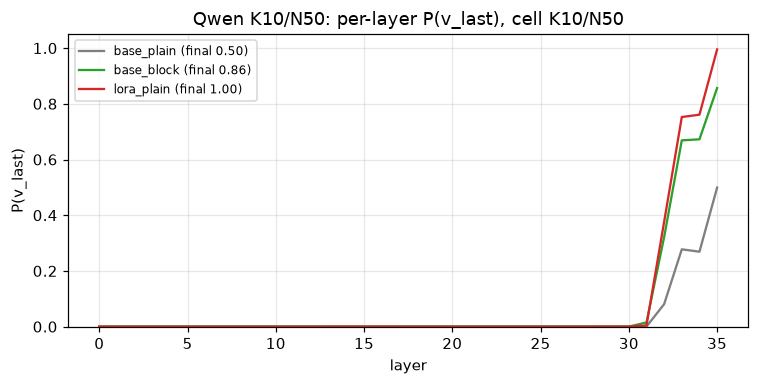

  corr(base_block, lora_plain) per-layer = 1.000


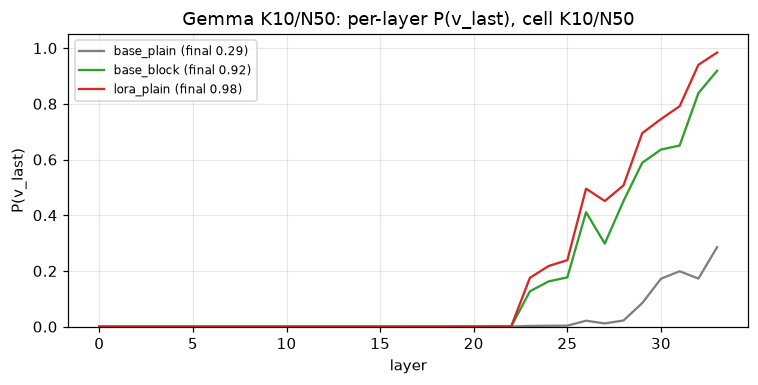

  corr(base_block, lora_plain) per-layer = 0.996


In [10]:
def block_plot(pathglob, title):
    fs=find(pathglob)
    if not fs: print('missing',pathglob); return
    d=jload(fs[0]); conds=d['conditions']
    plt.figure(figsize=(7,3.6))
    curves={}
    for name,color in [('base_plain','tab:gray'),('base_block','tab:green'),('lora_plain','tab:red')]:
        if name in conds:
            pl=conds[name]['CVQ']['p_last_per_layer']; curves[name]=pl
            plt.plot(pl,'-',color=color,label=f'{name} (final {pl[-1]:.2f})')
    plt.title(f'{title}: per-layer P(v_last), cell K{d["cell"]["keys"]}/N{d["cell"]["updates"]}')
    plt.xlabel('layer'); plt.ylabel('P(v_last)'); plt.ylim(0,1.05); plt.legend(fontsize=8); plt.show()
    if 'base_block' in curves and 'lora_plain' in curves:
        a,b=np.array(curves['base_block']),np.array(curves['lora_plain'])
        print(f'  corr(base_block, lora_plain) per-layer = {np.corrcoef(a,b)[0,1]:.3f}')
block_plot('lora_intervention/experiments/block_readout_results/results_K10N50.json','Qwen K10/N50')
block_plot('lora_intervention/experiments/gemma_results/block/results_K10N50.json','Gemma K10/N50')

**Result.** `base_plain` stays suppressed; **`base_block` and `lora_plain` rise together to the
same high P(v_last) at the same late layer** (per-layer correlation printed above is very high).

**Interpretation — "two roads, one readout".** The two fixes take *different upstream routes*
(prompt markers vs weight edits) but **converge on the same late readout locus**. The base model
*tracks* v_last but *suppresses* it; both fixes release the same readout.

**Caveat.** The companion linear probe is degenerate for `lora_plain` (see C5) — logit-lens is the
valid cross-condition comparison here. Cross-format activation patching is *not* meaningful (block
vs plain prompts aren't token-aligned), so we don't claim it.

## E3. Behavioral 3-way per-position sweep — *the headline figure*

**Question.** At **every** position (not just endpoints), how do base / Block / LoRA compare?
**Measured:** accuracy vs relative position at K10/N50 (the divergence cell), all three conditions,
for Qwen and Gemma.

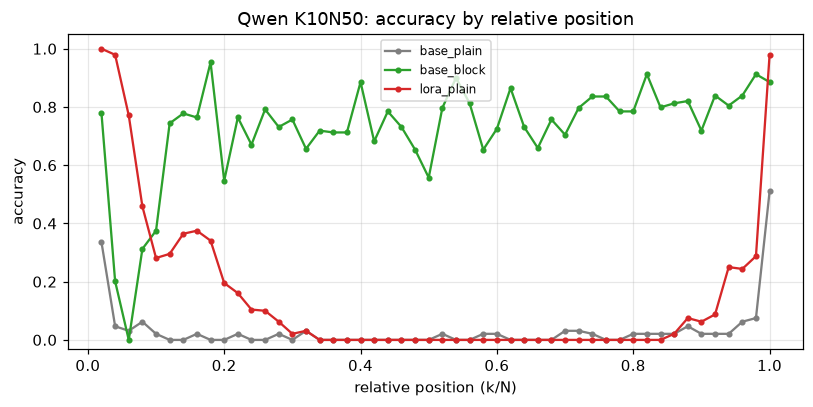

  interior mean — base 0.02 | block 0.72 | lora 0.12


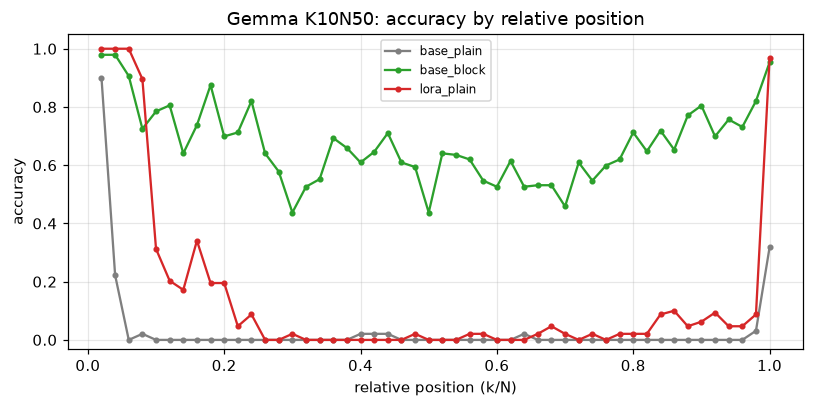

  interior mean — base 0.01 | block 0.66 | lora 0.11


In [11]:
def perpos_plot(pathglob, title, cell='K10N50'):
    fs=find(pathglob)
    if not fs: print('missing',pathglob); return
    d=jload(fs[0]);
    if cell not in d: print(cell,'not in',pathglob); return
    c=d[cell]; N=c['base_plain']['updates']
    plt.figure(figsize=(7.5,3.8))
    for name,color in [('base_plain','tab:gray'),('base_block','tab:green'),('lora_plain','tab:red')]:
        if name in c:
            pos=sorted(c[name]['positions'], key=lambda p:p['k'])
            xs=[p['k']/N for p in pos]; ys=[p['acc'] for p in pos]
            plt.plot(xs, ys, 'o-', ms=3, color=color, label=name)
    plt.title(f'{title} {cell}: accuracy by relative position'); plt.xlabel('relative position (k/N)')
    plt.ylabel('accuracy'); plt.ylim(-0.03,1.05); plt.legend(fontsize=8); plt.show()
    def imean(cn):
        return np.mean([p['acc'] for p in c[cn]['positions'] if 1<p['k']<N]) if cn in c else float('nan')
    print(f'  interior mean — base {imean("base_plain"):.2f} | block {imean("base_block"):.2f} | lora {imean("lora_plain"):.2f}')
perpos_plot('lora_intervention/experiments/behavioral_block_lora_results/results.json','Qwen')
perpos_plot('lora_intervention/experiments/gemma_results/behavioral/results.json','Gemma')

**Result — three distinct signatures (identical across families):**
- **base = U-shape** — only first & last positions have signal; the interior is ~0.
- **Block = flat-high** — genuine general position indexing across all depths.
- **LoRA = boundary-anchored decay** — perfect at the ends, collapses in the deep middle, worsens with N.

Interior means printed above (Qwen ≈ base 0.02 / block 0.72 / lora 0.12; Gemma ≈ 0.01 / 0.66 / 0.11).

**Interpretation — the money result.** Endpoints converge, **interior diverges**: Block installs
*real* position addressing; LoRA only *amplifies end-anchored retrieval*. This behaviorally explains
E1 (why LoRA's IVQ is N-bounded and decaying).

**Caveat.** Block dense cells run every interior position to the 200-trial cap (mid-accuracy never
early-stops), which is why this sweep is slow; endpoint-mode cells (K2/N30 etc.) have no interior by design.

## E4. Stage-3C causal ablation — does LoRA *amplify* the promoter heads?

**Question.** Ablate the promoter heads (C3) in base vs LoRA; does removing them hurt LoRA *more*
(amplification)? This also **resolves Finding 001** (an earlier n=50 result contradicted the paper).
**Method.** Zero each promoter head's `o_proj`-input slice; logit-lens ΔP(v_last); **n=200, paired
seeds**; bootstrap 95% CIs on the paired (LoRA−base) difference. **Measured:** per-cell paired Δ.

In [12]:
def ablation_table(pathglob, title, layer=None):
    fs=find(pathglob)
    if not fs: print('missing',pathglob); return
    d=jload(fs[0]); rows=[]
    for cell,cd in d['cells'].items():
        base=cd['base']['per_trial']; lora=cd['lora']['per_trial']
        L = layer or max(base[0], key=lambda k:int(k))  # readout ~ last stored layer
        bΔ=[t[L][1]-t[L][0] for t in base]; lΔ=[t[L][1]-t[L][0] for t in lora]
        pair=[a-b for a,b in zip(lΔ,bΔ)]
        plo,phi=boot_ci(pair)
        rows.append(dict(cell=cell, layer=f'L{L}',
                         base_norm=round(np.mean([t[L][0] for t in base]),2),
                         lora_norm=round(np.mean([t[L][0] for t in lora]),2),
                         base_Δ=round(np.mean(bΔ),3), lora_Δ=round(np.mean(lΔ),3),
                         paired=f'{np.mean(pair):+.3f} [{plo:+.3f},{phi:+.3f}]',
                         excl_zero=(plo<0)==(phi<0)))
    show_df(pd.DataFrame(rows), f'{title}: ablation ΔP(v_last)=ablated−normal; paired=(LoRA−base). '
            f'heads={d.get("promoter_heads")}')
ablation_table('lora_intervention/experiments/ablation_rerun_results/results.json','Qwen (n=200)')
ablation_table('lora_intervention/experiments/gemma_results/ablation/results.json','Gemma (n=200)')

*Qwen (n=200): ablation ΔP(v_last)=ablated−normal; paired=(LoRA−base). heads=['L32H3', 'L32H7', 'L31H12', 'L31H15', 'L32H10', 'L30H11', 'L32H0', 'L32H14']*

,cell,layer,base_norm,lora_norm,base_Δ,lora_Δ,paired,excl_zero
0,K2N5,L35,0.75,1.00,-0.094,-0.007,"+0.087 [+0.047,+0.129]",True
1,K2N50,L35,0.29,0.99,-0.060,-0.110,"-0.050 [-0.093,-0.008]",True


*Gemma (n=200): ablation ΔP(v_last)=ablated−normal; paired=(LoRA−base). heads=['L23H3', 'L23H1', 'L23H0', 'L23H6', 'L23H7', 'L17H5', 'L17H0', 'L29H4']*

,cell,layer,base_norm,lora_norm,base_Δ,lora_Δ,paired,excl_zero
0,K2N30,L33,0.64,1.00,-0.295,-0.824,"-0.529 [-0.598,-0.456]",True
1,K10N50,L33,0.21,0.98,-0.189,-0.927,"-0.738 [-0.793,-0.677]",True


**Result.** **Every paired (LoRA−base) CI excludes zero** — ablating the promoter heads reduces
P(v_last) significantly more under LoRA than base, in both families. Cleanest at the failure cell,
where base has little v_last to remove and LoRA's is almost entirely head-driven. Gemma's effect is
*larger* than Qwen's.

**Interpretation.** LoRA **amplifies** the causal contribution of pre-existing promoter heads to the
current-value readout — the §7 mechanism, now confirmed cross-family.

**Caveats (don't gloss).**
- Original paper reported −0.28/−0.40 magnitudes from a TransformerLens run; this HF-hook ablation is
  *gentler* (same baselines, smaller Δ). **Direction + significance** are what resolve Finding 001;
  the paper should use these n=200 numbers, not the old magnitudes.
- Qwen's ablation cell K2/N5 is a **near-success** cell (base CVQ 0.77); K2/N50 (Qwen) and K10/N50
  (Gemma) are the genuine-failure cells — read those as the primary evidence.
- Gemma promoters are mid-depth (L23), upstream of the L33 readout; at the mild cell both base & LoRA
  collapse near the readout, so the amplification reads cleanest at the failure cell / mid-layers.

---
## Cross-family synthesis — same function, different circuit

Pulling C3 + E1–E4 together for Qwen vs Gemma.

In [13]:
synth = pd.DataFrame([
    dict(aspect='top promoter head (FVQ−CVQ)', Qwen='L31H15 +0.75', Gemma='L23H3 +0.73'),
    dict(aspect='promoter cluster depth',       Qwen='L26–L31 (late)', Gemma='L23 (mid) +L17'),
    dict(aspect='readout layer',                Qwen='~L35/36', Gemma='~L33/34'),
    dict(aspect='E1 endpoints generalize',      Qwen='to ~5×', Gemma='to ~5×'),
    dict(aspect='E1 interior (IVQ) with N',     Qwen='0.56→0.07', Gemma='0.49→0.05'),
    dict(aspect='E3 interior mean (K10/N50)',   Qwen='base .02 / blk .72 / lora .12',
                                                Gemma='base .01 / blk .66 / lora .11'),
    dict(aspect='E4 paired Δ (failure cell)',   Qwen='−0.230', Gemma='−0.738'),
    dict(aspect='attention',                    Qwen='16 heads (MHA)', Gemma='8 heads (GQA)'),
])
show_df(synth, 'Qwen vs Gemma: functional results match; head topology differs.')

*Qwen vs Gemma: functional results match; head topology differs.*

,aspect,Qwen,Gemma
0,top promoter head (FVQ−CVQ),L31H15 +0.75,L23H3 +0.73
1,promoter cluster depth,L26–L31 (late),L23 (mid) +L17
2,readout layer,~L35/36,~L33/34
3,E1 endpoints generalize,to ~5×,to ~5×
4,E1 interior (IVQ) with N,0.56→0.07,0.49→0.05
5,E3 interior mean (K10/N50),base .02 / blk .72 / lora .12,base .01 / blk .66 / lora .11
6,E4 paired Δ (failure cell),−0.230,−0.738
7,attention,16 heads (MHA),8 heads (GQA)


**Takeaway for the supervisor.** Qwen and Gemma independently reproduce the *entire* functional
story — late suppressed-then-released readout, equally-specialised promoter heads, convergent
Block/LoRA readout, base-U/Block-flat/LoRA-decay interior, and LoRA amplification of promoter heads.
But the promoter/suppressor heads sit at **different depths** across families. So it's a **convergent
mechanism on different circuits** — stronger evidence that the effect is architectural than an
exact head-for-head match would be.

## Open items / honest limitations
- Ablation magnitudes are HF-hook (gentler than TL); report direction+significance, not the old numbers.
- E2 probe degenerate for LoRA (too-good-to-probe) — logit-lens is the valid comparison.
- Gemma ablation #4 uses FVQ−CVQ-ranked heads (same metric as Qwen); a causal head-search could refine.
- Cross-model absolute accuracies aren't tokenizer-matched — read patterns.
- Single seed per config in the mechanistic runs (behavioral uses many trials + Wilson CIs).